<a href="https://colab.research.google.com/github/VasilinaFrolova/-/blob/main/%D0%92%D0%B8%D0%B7%D1%83%D0%B0%D0%BB%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F_%D0%B4%D0%B5%D0%BC%D0%BE%D0%B3%D1%80%D0%B0%D1%84_%D0%BF%D1%80%D0%B8%D0%B7%D0%BD%D0%B0%D0%BA%D0%BE%D0%B2_%D1%80%D0%B5%D1%81%D0%BF%D0%BE%D0%BD%D0%B4%D0%B5%D0%BD%D1%82%D0%BE%D0%B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Установка и импорт необходимых библиотек
# ============================================================
!pip install -q pandas matplotlib seaborn openpyxl

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import io
import warnings
warnings.filterwarnings('ignore')   # скрываем незначительные предупреждения

# Настройка внешнего вида графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
# 2. Загрузка файла (вручную через кнопку "Выбрать файл")
# ------------------------------------------------------------
print("Пожалуйста, загрузите файл 'Восприятие рекламы (Ответы) (1).xlsx'")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# ------------------------------------------------------------
# 3. Чтение листов с демографическими данными
# ------------------------------------------------------------
try:
    df_gender   = pd.read_excel(filename, sheet_name='ваш пол')
    df_age      = pd.read_excel(filename, sheet_name='ваш возраст')
    df_edu      = pd.read_excel(filename, sheet_name='ваше образование')
    df_advert   = pd.read_excel(filename, sheet_name='связь работы и рекламы')
except Exception as e:
    print(f"Ошибка при чтении отдельных листов: {e}")
    print("Пробую читать из основного листа 'Ответы на форму (1)'...")
    df_main = pd.read_excel(filename, sheet_name='Ответы на форму (1)')
    col_map = {
        'Ваш пол': 'Пол',
        'Ваш возраст': 'Возраст',
        'Уровень профессионального образования': 'Образование',
        'Связана ли сфера Вашей непосредственной деятельности/профессия с рекламой?': 'Связь с рекламой'
    }
    df_all = df_main[list(col_map.keys())].rename(columns=col_map).dropna()
else:
    # Переименовываем столбцы и объединяем в один DataFrame
    df_gender.columns  = ['Пол']
    df_age.columns     = ['Возраст']
    df_edu.columns     = ['Образование']
    df_advert.columns  = ['Связь с рекламой']

    df_all = pd.concat([df_gender, df_age, df_edu, df_advert], axis=1).dropna()

print("Данные загружены. Первые строки:")
display(df_all.head())

Пожалуйста, загрузите файл 'Восприятие рекламы (Ответы) (1).xlsx'


Saving Восприятие рекламы (Ответы) (1).xlsx to Восприятие рекламы (Ответы) (1) (1).xlsx
Данные загружены. Первые строки:


,Пол,Возраст,Образование,Связь с рекламой
0,Женский,18–24,Высшее,Нет
1,Женский,45–54,Высшее,Нет
2,Мужской,18–24,Высшее,Нет
3,Женский,45–54,Высшее,Нет
4,Женский,55–64,Высшее,Нет


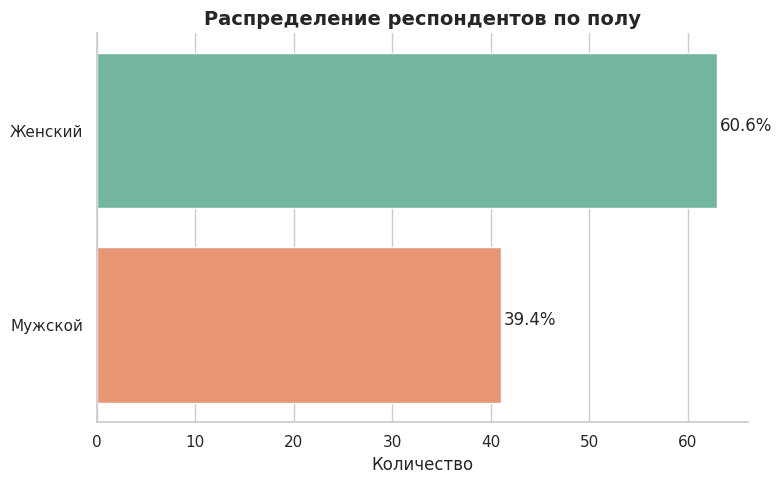

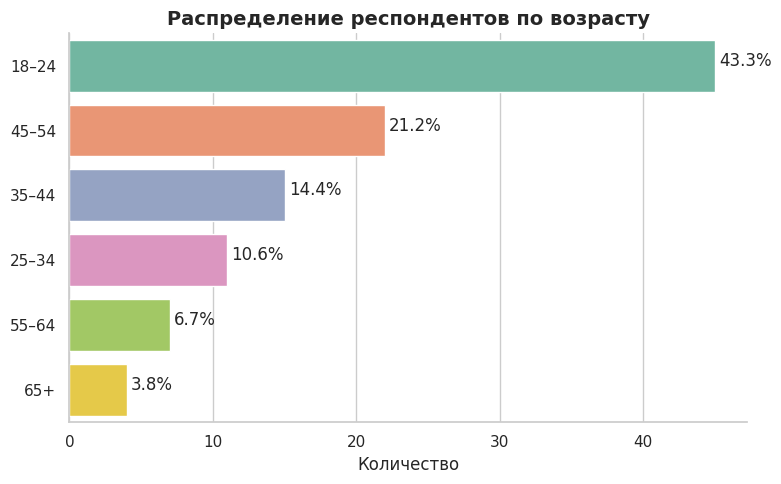

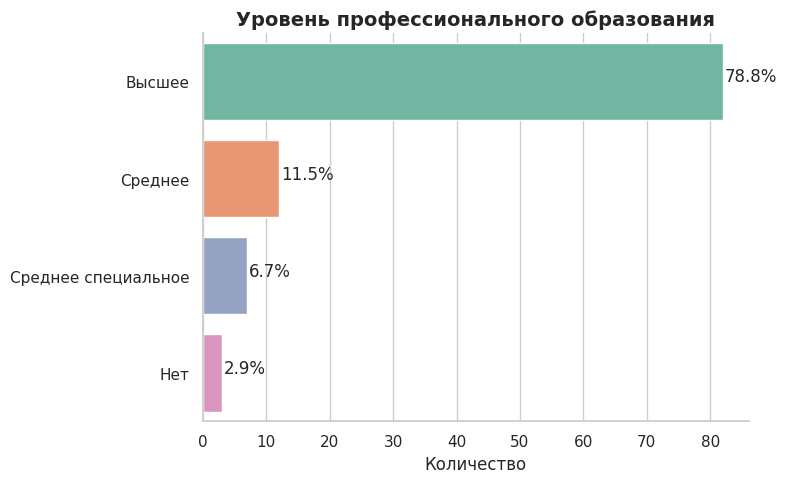

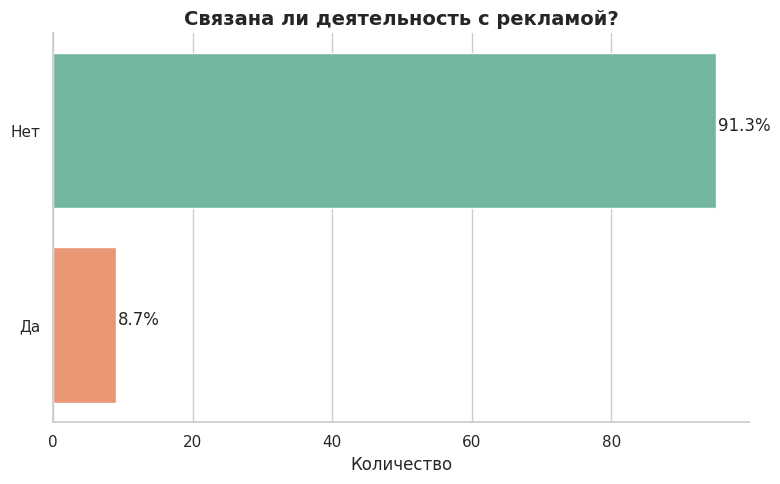

In [ ]:
# 4. Функция для построения countplot (гистограммы частот)
# ------------------------------------------------------------
def plot_count(series, title, xlabel, palette="Set2"):
    """Гистограмма для категориальной переменной."""
    plt.figure(figsize=(8, 5))
    ax = sns.countplot(
        y=series,
        order=series.value_counts().index,
        palette=palette
    )
    # Добавляем проценты на столбцы
    total = len(series)
    for p in ax.patches:
        percentage = f'{100 * p.get_width() / total:.1f}%'
        ax.annotate(percentage, (p.get_width() + 0.3, p.get_y() + 0.4))

    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    sns.despine()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 5. Построение графиков
# ------------------------------------------------------------
plot_count(df_all['Пол'], 'Распределение респондентов по полу', 'Количество')
plot_count(df_all['Возраст'], 'Распределение респондентов по возрасту', 'Количество')
plot_count(df_all['Образование'], 'Уровень профессионального образования', 'Количество')
plot_count(df_all['Связь с рекламой'], 'Связана ли деятельность с рекламой?', 'Количество')

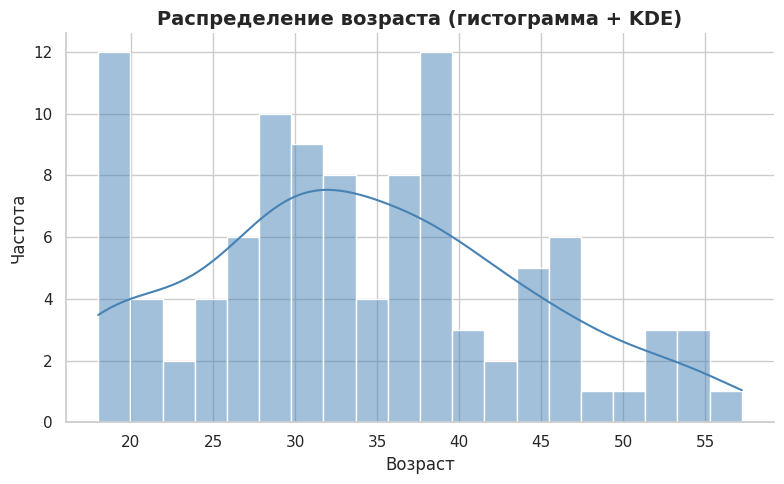

In [ ]:
# 6. Пример построения гистограммы с KDE (плотностью)
#    (замените столбец на реальный числовой, если он есть)
# ------------------------------------------------------------
# Допустим, у нас есть числовой столбец 'Возраст' (но он категориальный).
# Для демонстрации создадим искусственный непрерывный признак.
import numpy as np
np.random.seed(42)
df_all['Возраст_числовой'] = np.random.normal(loc=35, scale=12, size=len(df_all))
df_all['Возраст_числовой'] = df_all['Возраст_числовой'].clip(18, 70)

plt.figure(figsize=(8, 5))
sns.histplot(
    df_all['Возраст_числовой'],
    bins=20,
    kde=True,
    color='steelblue',
    edgecolor='white'
)
plt.title('Распределение возраста (гистограмма + KDE)', fontsize=14, fontweight='bold')
plt.xlabel('Возраст')
plt.ylabel('Частота')
sns.despine()
plt.tight_layout()
plt.show()

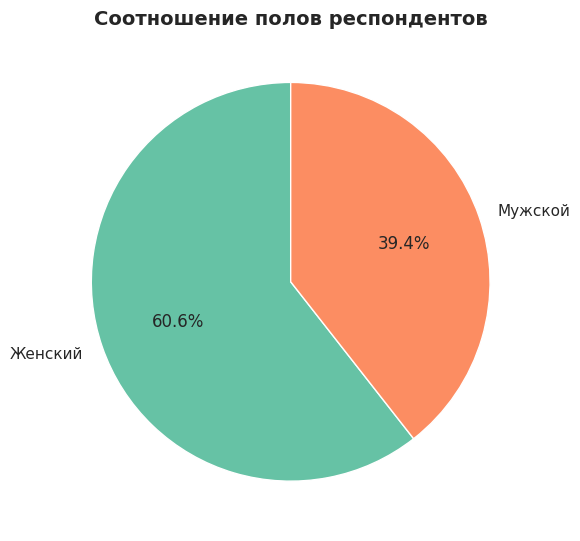

In [ ]:
# Круговая диаграмма для пола
plt.figure(figsize=(6, 6))
df_all['Пол'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("Set2"),
    wedgeprops={'edgecolor': 'white'}
)
plt.title('Соотношение полов респондентов', fontsize=14, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.show()

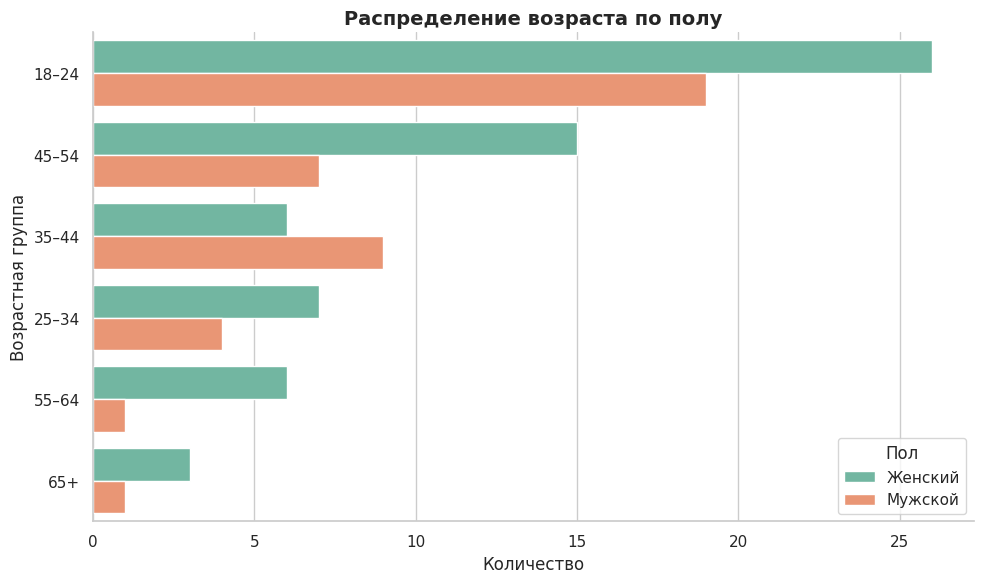

In [ ]:
# Совместное распределение двух переменных (пол и возраст)
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_all,
    y='Возраст',
    hue='Пол',
    order=df_all['Возраст'].value_counts().index,
    palette='Set2'
)
plt.title('Распределение возраста по полу', fontsize=14, fontweight='bold')
plt.xlabel('Количество')
plt.ylabel('Возрастная группа')
plt.legend(title='Пол')
sns.despine()
plt.tight_layout()
plt.show()